## Loading and Previewing the Dataset

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Step 1: Load the dataset
file_path = '/content/mountains_vs_beaches_preferences.csv'  # Update with your local file path if needed
data = pd.read_csv(file_path)

# View the first few rows of the dataset
data.head()


,Age,Gender,Income,Education_Level,Travel_Frequency,Preferred_Activities,Vacation_Budget,Location,Proximity_to_Mountains,Proximity_to_Beaches,Favorite_Season,Pets,Environmental_Concerns,Preference
0,56,male,71477,bachelor,9,skiing,2477,urban,175,267,summer,0,1,1
1,69,male,88740,master,1,swimming,4777,suburban,228,190,fall,0,1,0
2,46,female,46562,master,0,skiing,1469,urban,71,280,winter,0,0,1
3,32,non-binary,99044,high school,6,hiking,1482,rural,31,255,summer,1,0,1
4,60,female,106583,high school,5,sunbathing,516,suburban,23,151,winter,1,1,0


# DATA PREPROCESSING

## Exploratory Data Analysis

In [54]:
# Step 2: Display basic information about the dataset
print("Dataset Information:")
data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52444 entries, 0 to 52443
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     52444 non-null  int64
 1   Gender                  52444 non-null  int64
 2   Income                  52444 non-null  int64
 3   Education_Level         52444 non-null  int64
 4   Travel_Frequency        52444 non-null  int64
 5   Preferred_Activities    52444 non-null  int64
 6   Vacation_Budget         52444 non-null  int64
 7   Location                52444 non-null  int64
 8   Proximity_to_Mountains  52444 non-null  int64
 9   Proximity_to_Beaches    52444 non-null  int64
 10  Favorite_Season         52444 non-null  int64
 11  Pets                    52444 non-null  int64
 12  Environmental_Concerns  52444 non-null  int64
 13  Preference              52444 non-null  int64
dtypes: int64(14)
memory usage: 5.6 MB


In [55]:
# Step 3: Display dataset statistic and summary
print("\nDataset Summary:")
print(data.describe())


Dataset Summary:
                Age        Gender         Income  Education_Level  \
count  52444.000000  52444.000000   52444.000000     52444.000000   
mean      43.507360      0.993250   70017.271280         1.492888   
std       14.985597      0.816001   28847.560428         1.115580   
min       18.000000      0.000000   20001.000000         0.000000   
25%       31.000000      0.000000   45048.250000         0.000000   
50%       43.000000      1.000000   70167.000000         1.000000   
75%       56.000000      2.000000   95108.500000         2.000000   
max       69.000000      2.000000  119999.000000         3.000000   

       Travel_Frequency  Preferred_Activities  Vacation_Budget      Location  \
count      52444.000000          52444.000000     52444.000000  52444.000000   
mean           4.489265              1.496282      2741.799062      1.000210   
std            2.876130              1.115204      1296.922423      0.816251   
min            0.000000              0.0

In [56]:
# Step 4: Check for missing values
print("\nMissing Values in Each Column:")
print(data.isnull().sum())


Missing Values in Each Column:
Age                       0
Gender                    0
Income                    0
Education_Level           0
Travel_Frequency          0
Preferred_Activities      0
Vacation_Budget           0
Location                  0
Proximity_to_Mountains    0
Proximity_to_Beaches      0
Favorite_Season           0
Pets                      0
Environmental_Concerns    0
Preference                0
dtype: int64


In [57]:
# Step 5: Distribution of the target variable
print("\nDistribution of Target Variable (Preference):")
print(data['Preference'].value_counts())


Distribution of Target Variable (Preference):
Preference
0    39296
1    13148
Name: count, dtype: int64


## Turning Data  into Numerical values

Saving then new  dataset

In [58]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Apply label encoding to the 'Education_Level' column
label_encoder = LabelEncoder()
data['Education_Level'] = label_encoder.fit_transform(data['Education_Level'])

# Step 2: Specify the remaining categorical columns for one-hot encoding
categorical_columns = ['Gender', 'Preferred_Activities', 'Location', 'Favorite_Season']  # Exclude 'Education_Level'

# Step 3: Use get_dummies for one-hot encoding
encoded_data = pd.get_dummies(data, columns=categorical_columns, drop_first=True, dtype=int)

# Step 4: Display the dataset after encoding
print("Dataset after Encoding (Education_Level Label Encoded, Others One-Hot Encoded):")
print(encoded_data.head())

# Step 5: Check the shape of the dataset
print("\nShape of the dataset before encoding:", data.shape)
print("Shape of the dataset after encoding:", encoded_data.shape)

Dataset after Encoding (Education_Level Label Encoded, Others One-Hot Encoded):
   Age  Income  Education_Level  Travel_Frequency  Vacation_Budget  \
0   56   71477                0                 9             2477   
1   69   88740                3                 1             4777   
2   46   46562                3                 0             1469   
3   32   99044                2                 6             1482   
4   60  106583                2                 5              516   

   Proximity_to_Mountains  Proximity_to_Beaches  Pets  Environmental_Concerns  \
0                     175                   267     0                       1   
1                     228                   190     0                       1   
2                      71                   280     0                       0   
3                      31                   255     1                       0   
4                      23                   151     1                       1   

   Preferenc

In [59]:
# Step 6: Save the encoded dataset to a CSV file
output_file_path = 'encoded_dataset.csv'  # Specify your desired file name and path
encoded_data.to_csv(output_file_path, index=False)

print(f"Encoded dataset has been saved to: {output_file_path}")


Encoded dataset has been saved to: encoded_dataset.csv


In [60]:
# Step 6: Define the matrix of features (X) and target vector (y)
X = encoded_data.drop(columns=['Preference'])  # Drop the target variable column
y = encoded_data['Preference']  # Define the target variable

# Display the shapes of the feature matrix and target vector
print("Shape of Feature Matrix (X):", X.shape)
print("Shape of Target Vector (y):", y.shape)

# Display the first few rows of the feature matrix and target vector
print("\nFeature Matrix (X):")
print(X.head())

print("\nTarget Vector (y):")
print(y.head())


Shape of Feature Matrix (X): (52444, 19)
Shape of Target Vector (y): (52444,)

Feature Matrix (X):
   Age  Income  Education_Level  Travel_Frequency  Vacation_Budget  \
0   56   71477                0                 9             2477   
1   69   88740                3                 1             4777   
2   46   46562                3                 0             1469   
3   32   99044                2                 6             1482   
4   60  106583                2                 5              516   

   Proximity_to_Mountains  Proximity_to_Beaches  Pets  Environmental_Concerns  \
0                     175                   267     0                       1   
1                     228                   190     0                       1   
2                      71                   280     0                       0   
3                      31                   255     1                       0   
4                      23                   151     1                      

## Exploratory Data Analysis

In [63]:
# Load the encoded dataset
data = pd.read_csv('encoded_dataset.csv')

<ipython-input-64-1ed37c071ff3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Preference', palette='pastel')


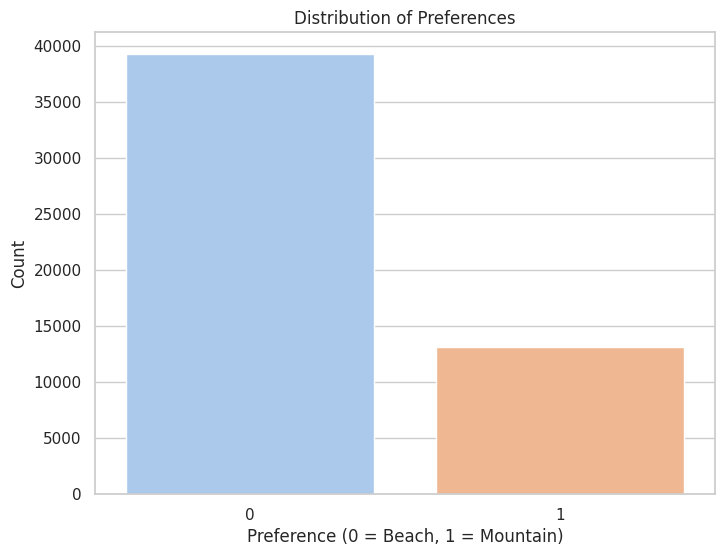

In [64]:
# Plot 1: Distribution of Preferences (Bar Plot)
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Preference', palette='pastel')
plt.title("Distribution of Preferences")
plt.xlabel("Preference (0 = Beach, 1 = Mountain)")
plt.ylabel("Count")
plt.show()


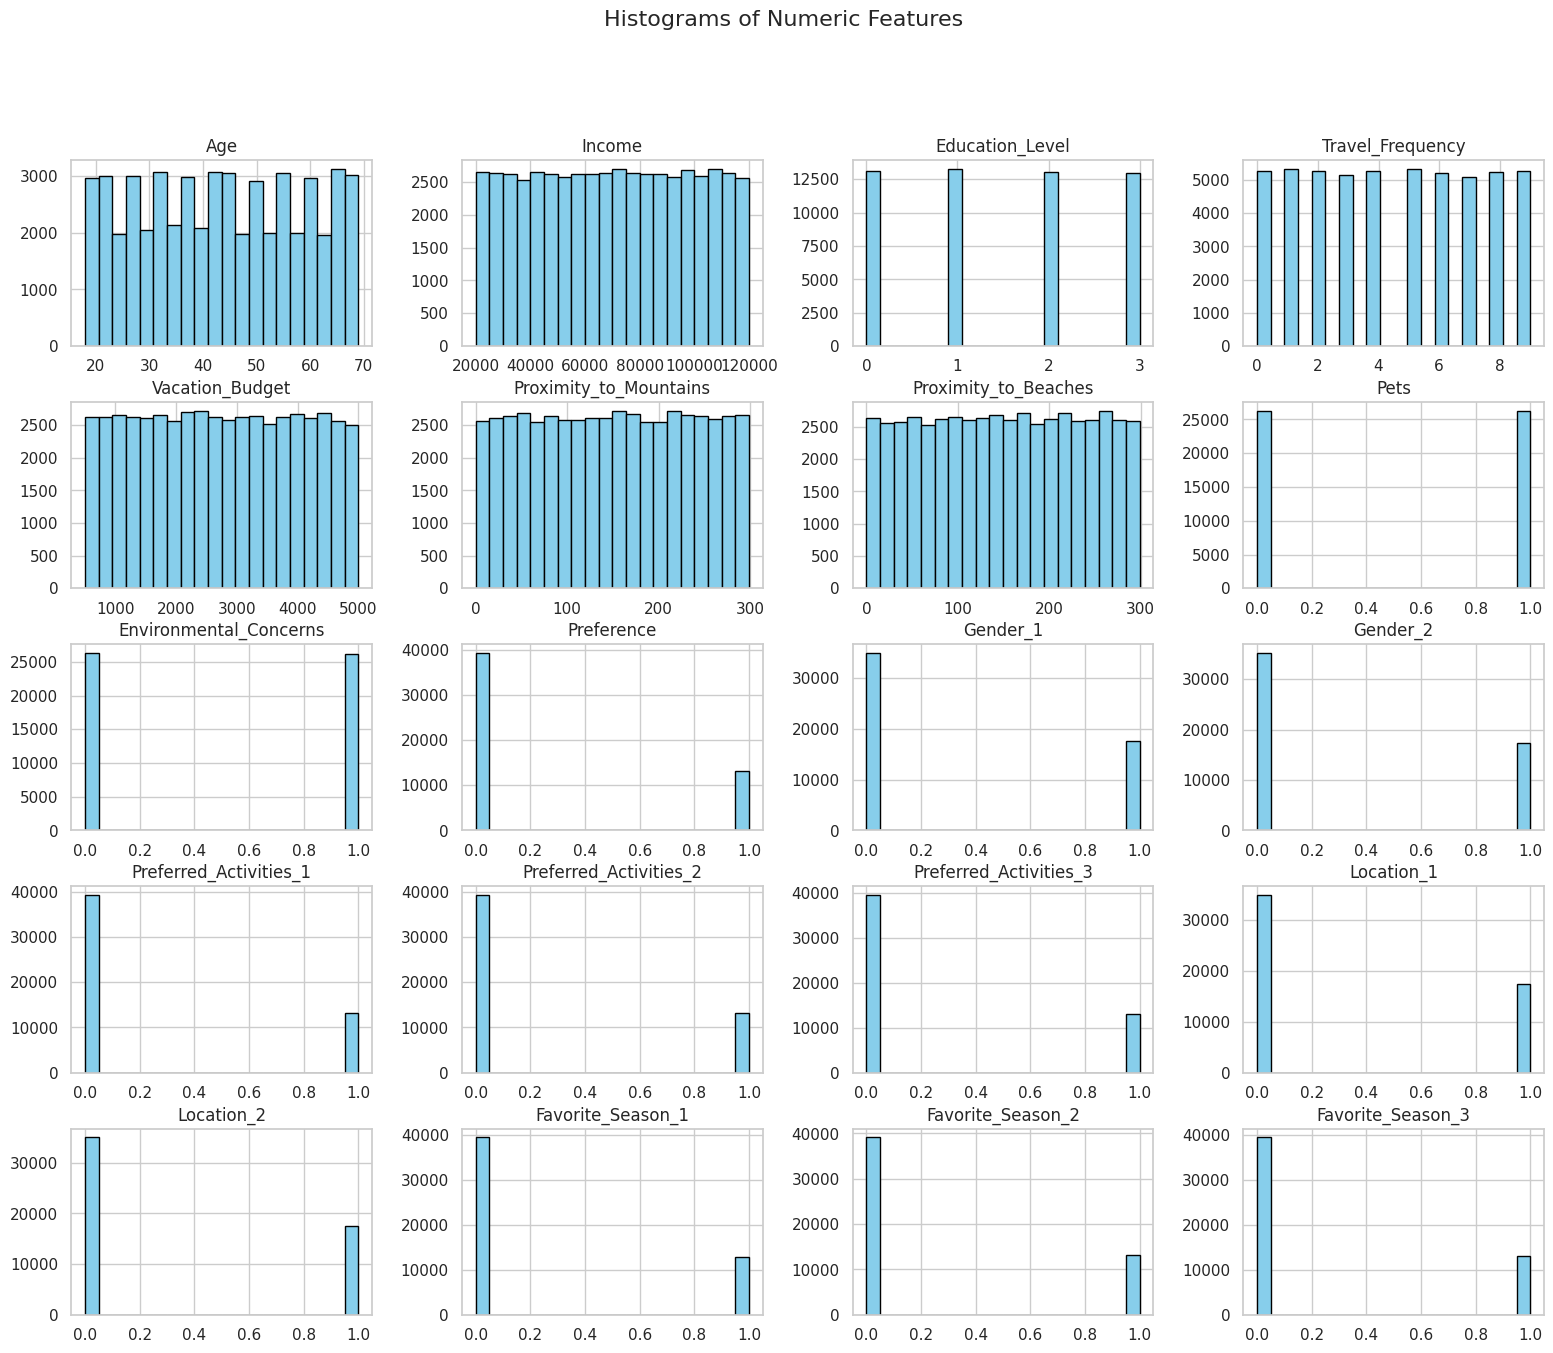

In [68]:
# Plot 2: Histogram for Numeric Features
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns
data[numeric_columns].hist(bins=20, figsize=(19, 15), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.show()

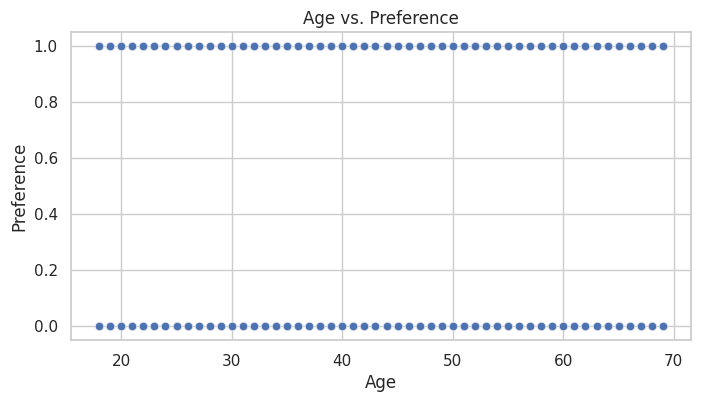

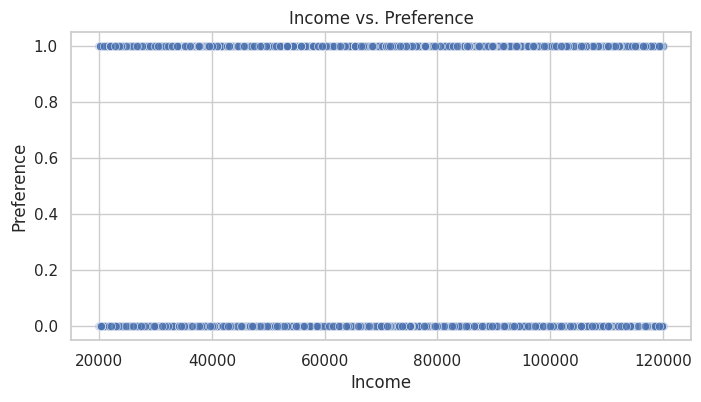

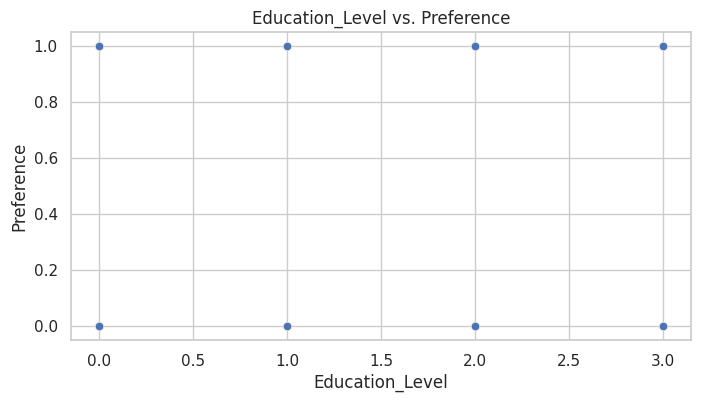

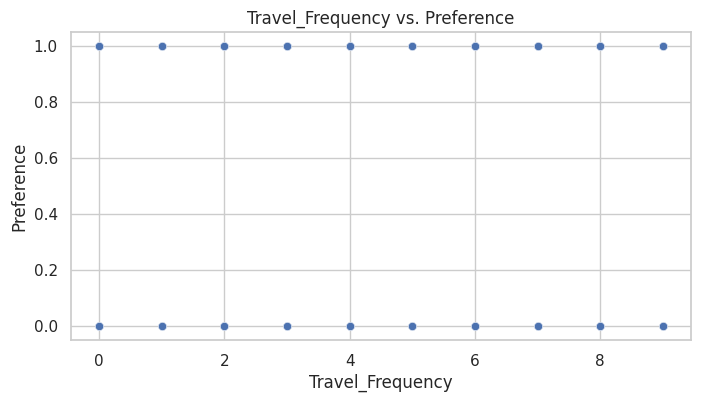

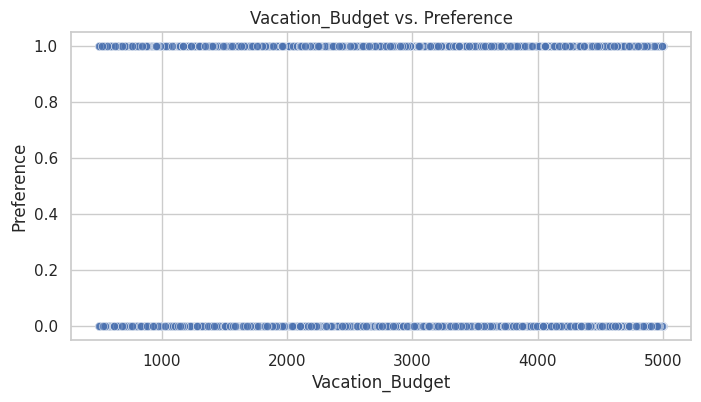

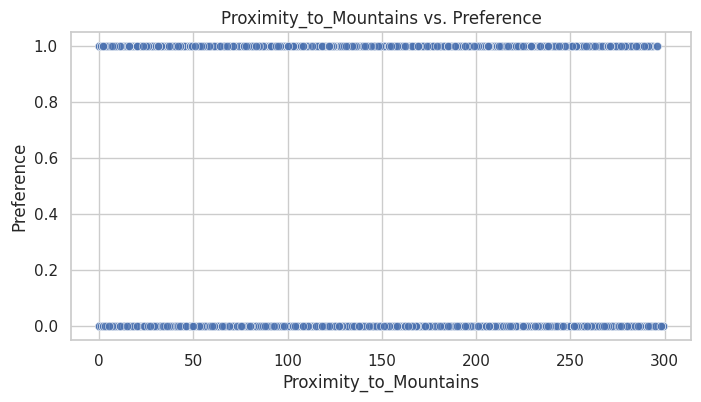

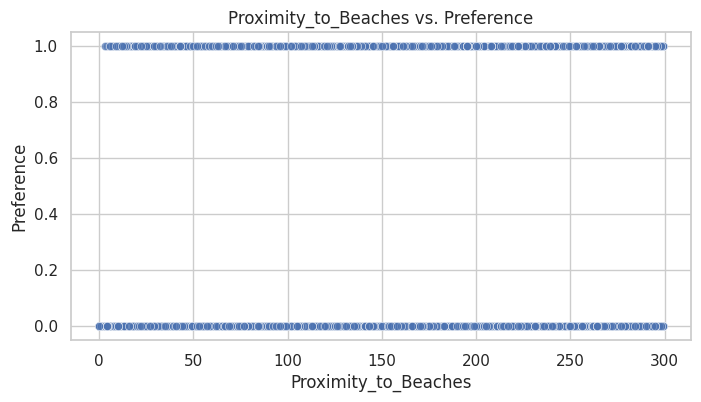

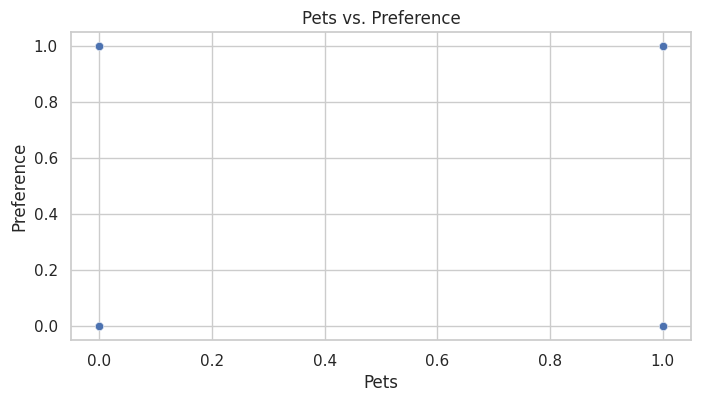

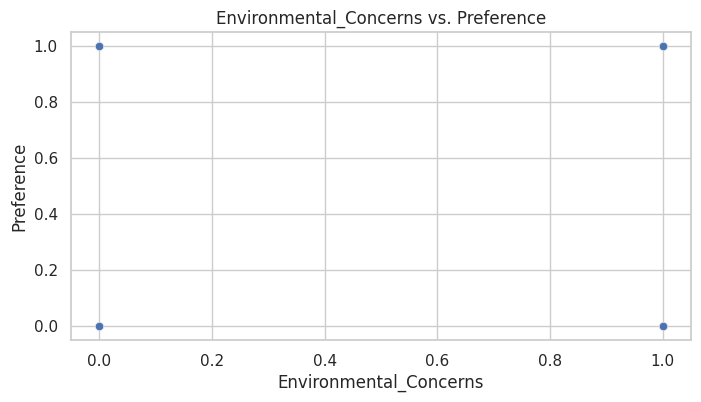

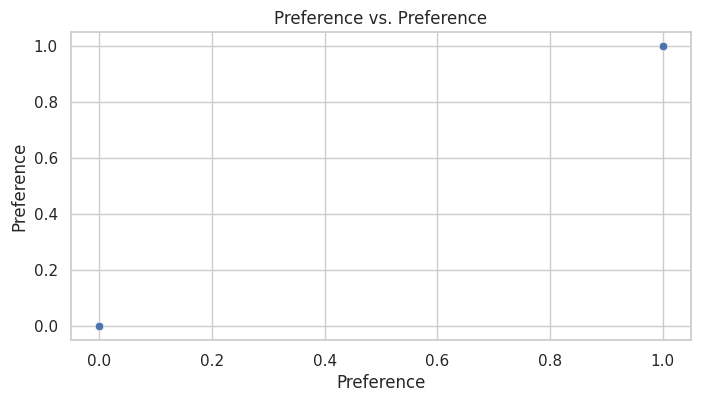

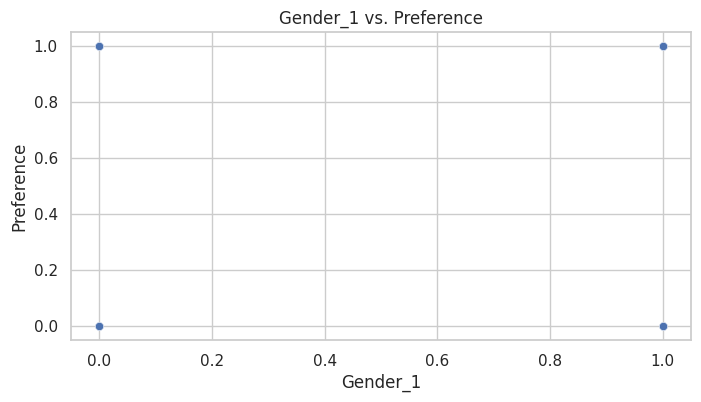

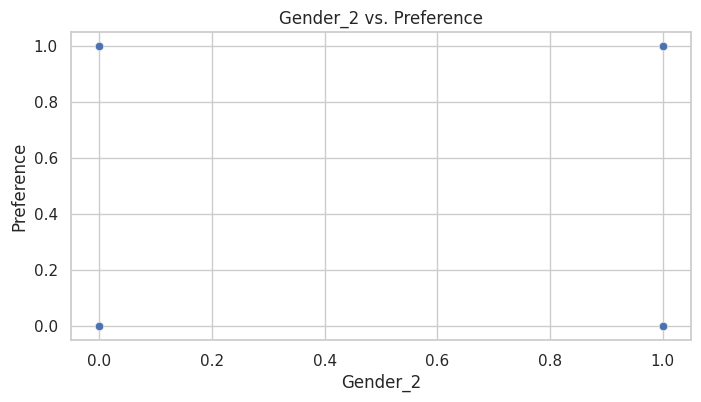

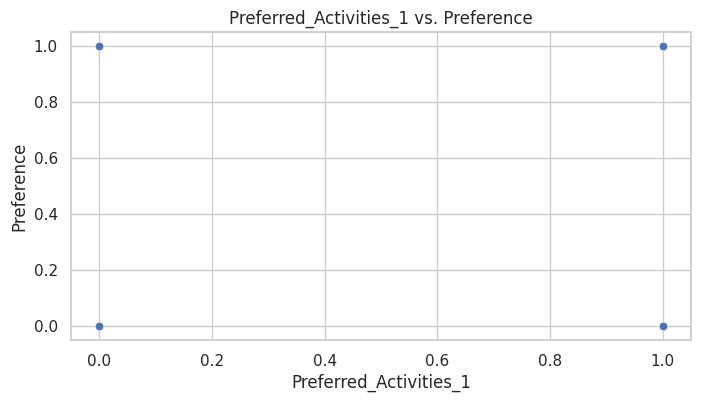

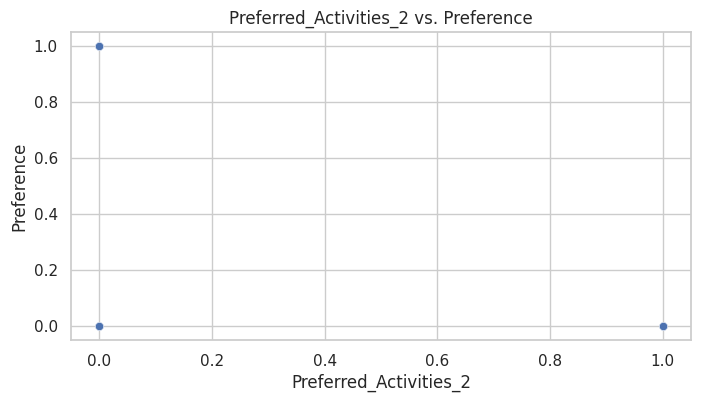

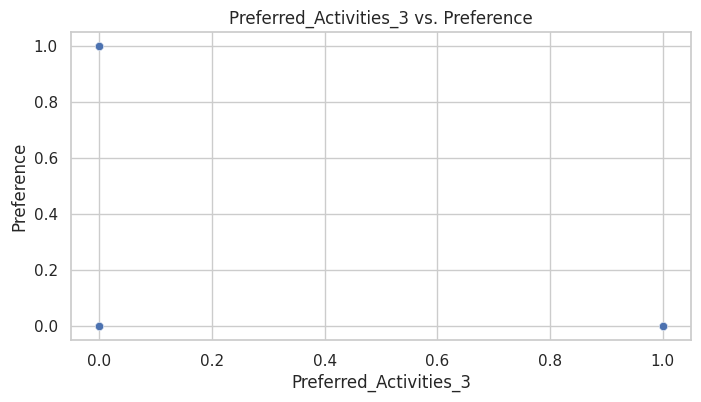

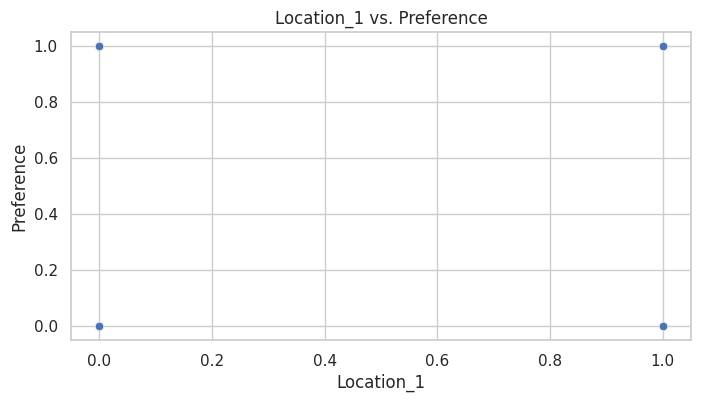

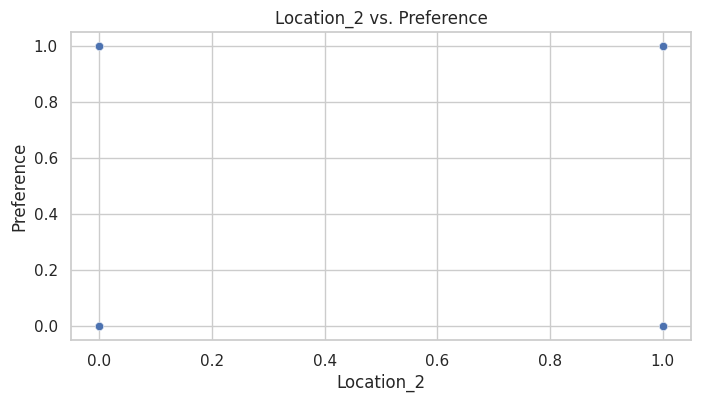

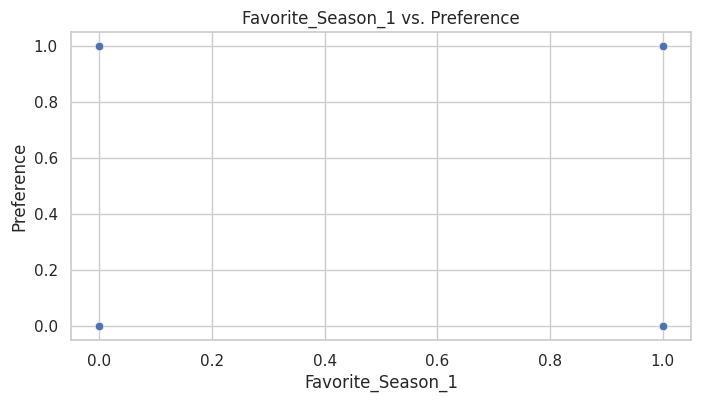

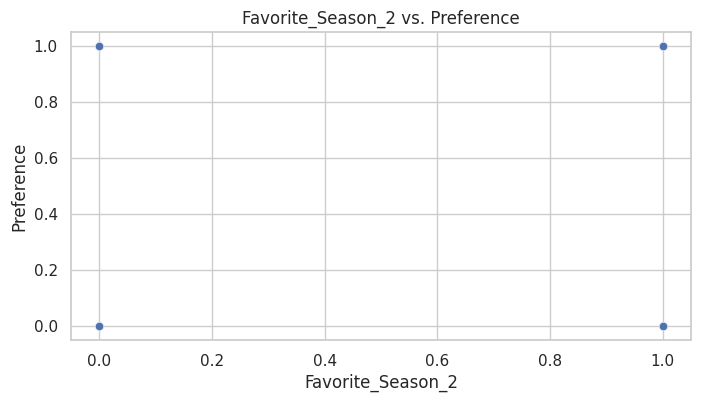

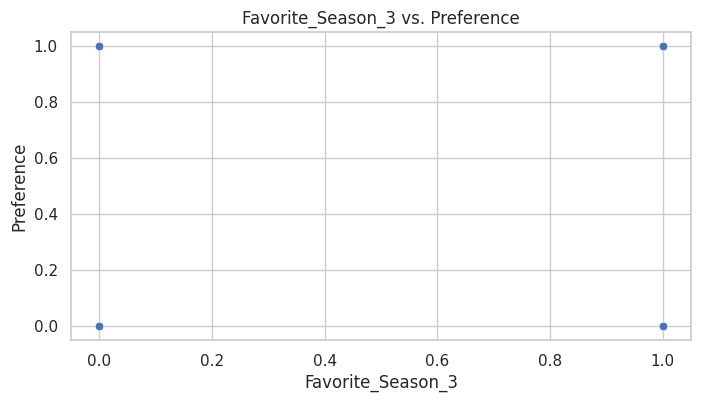

In [70]:
#Plot 3: Scatter plots for numerical features vs. target
numerical_cols = data.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=data, x=col, y='Preference', alpha=0.7)
    plt.title(f'{col} vs. Preference')
    plt.xlabel(col)
    plt.ylabel('Preference')
    plt.show()


<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


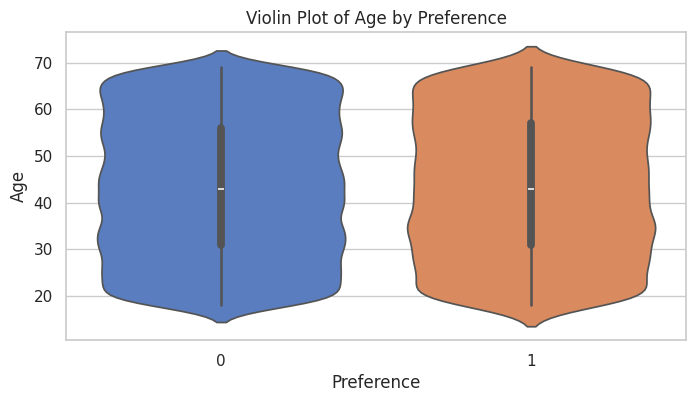

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


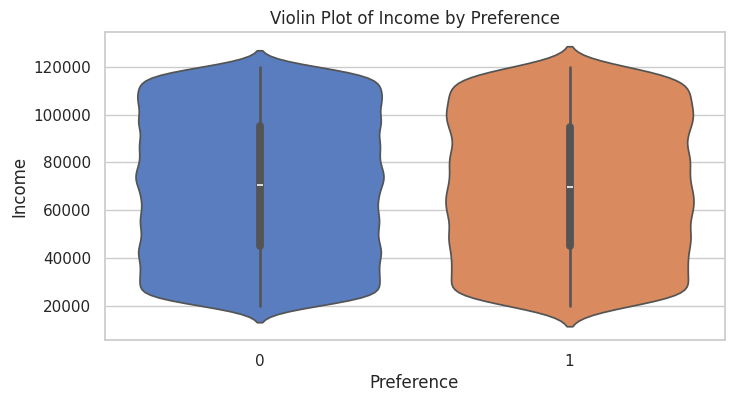

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


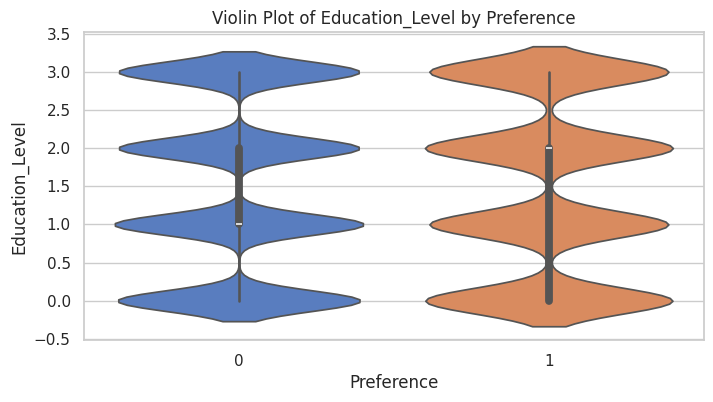

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


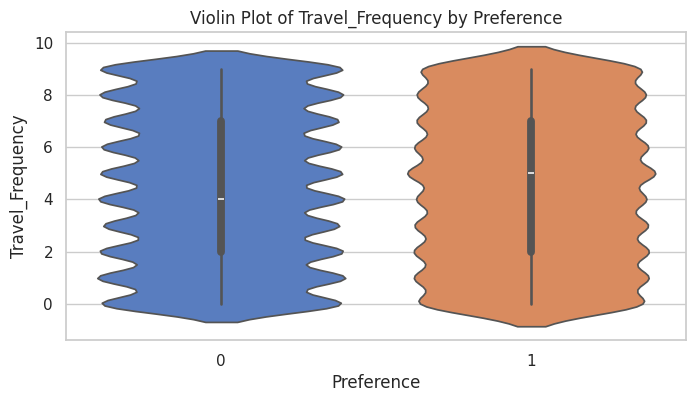

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


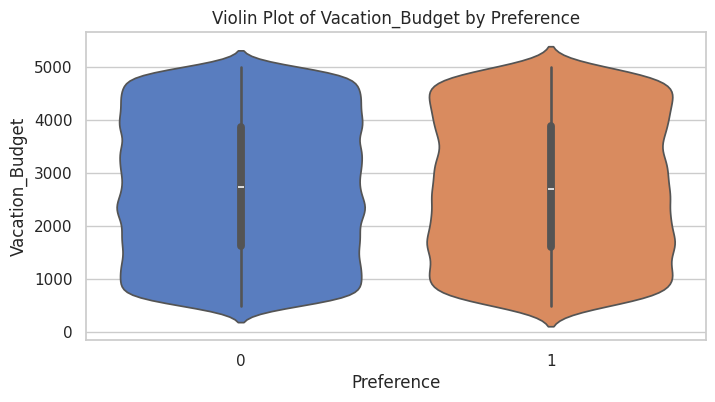

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


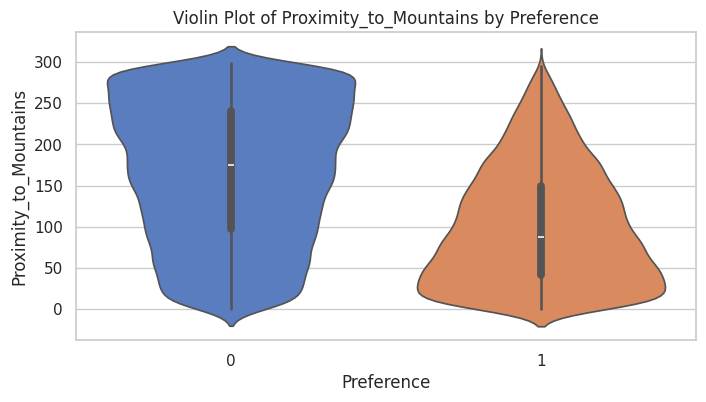

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


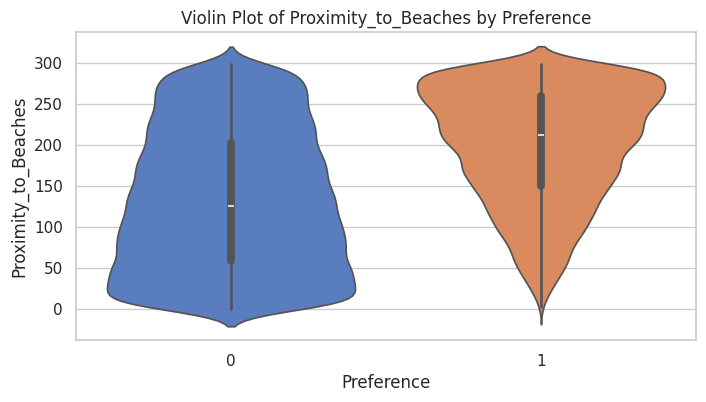

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


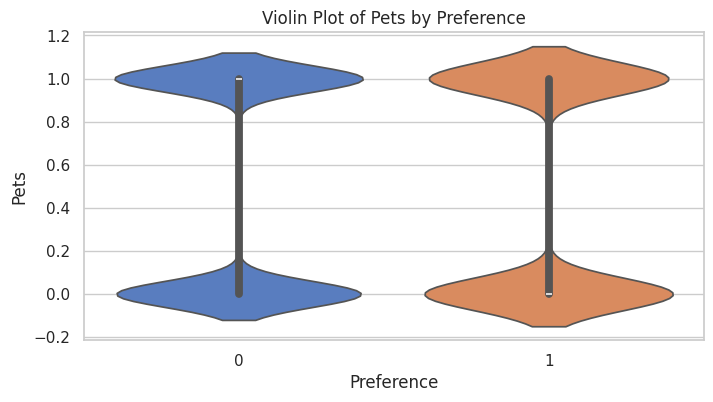

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


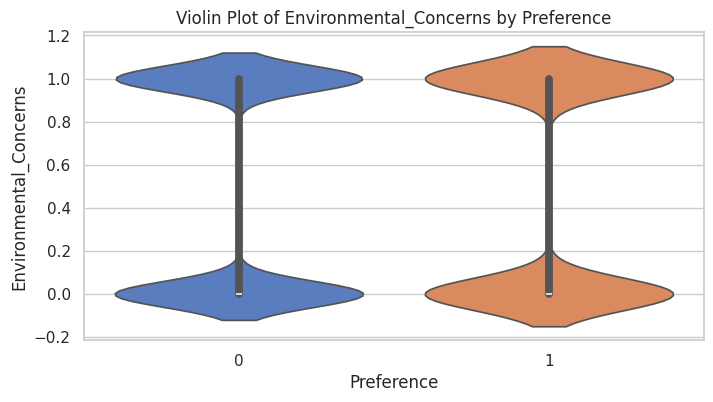

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


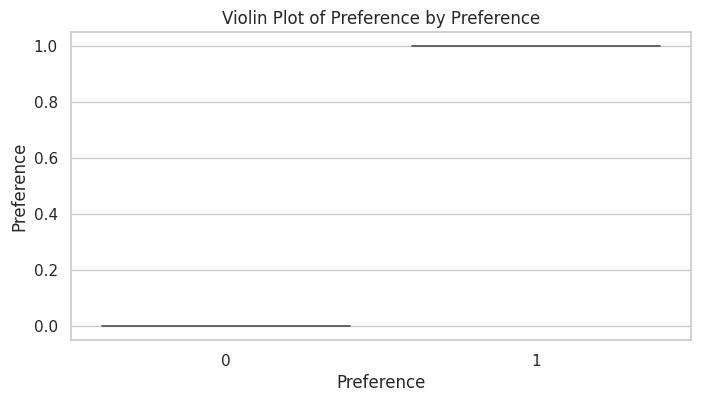

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


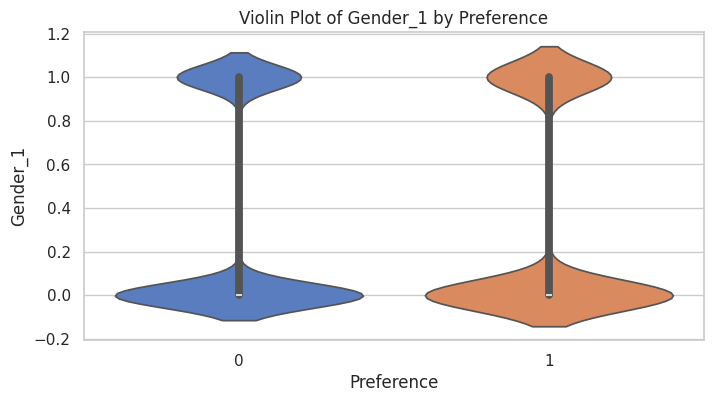

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


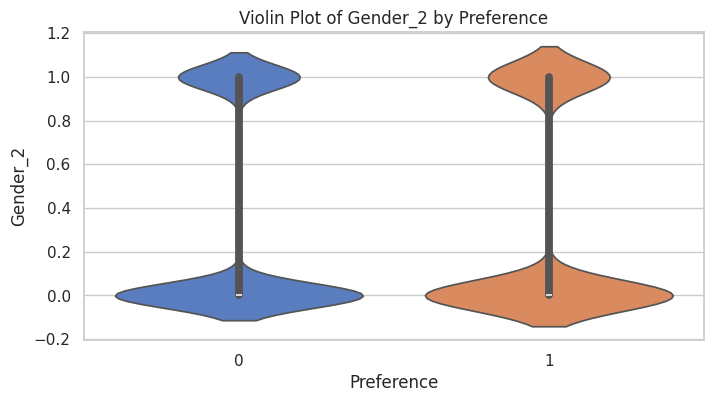

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


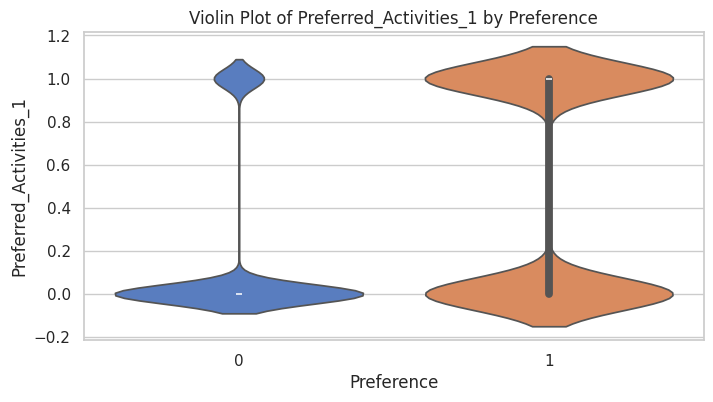

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


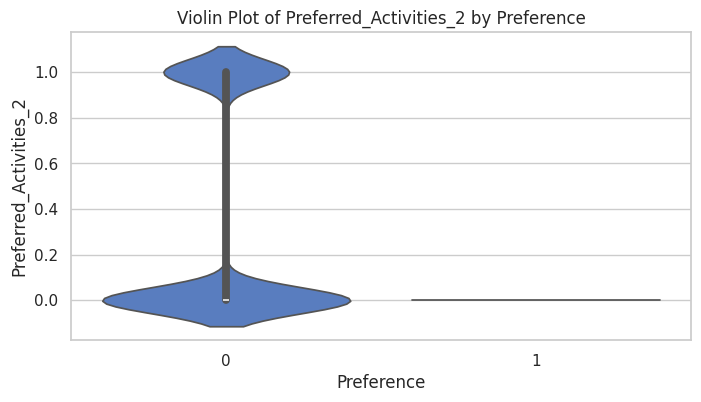

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


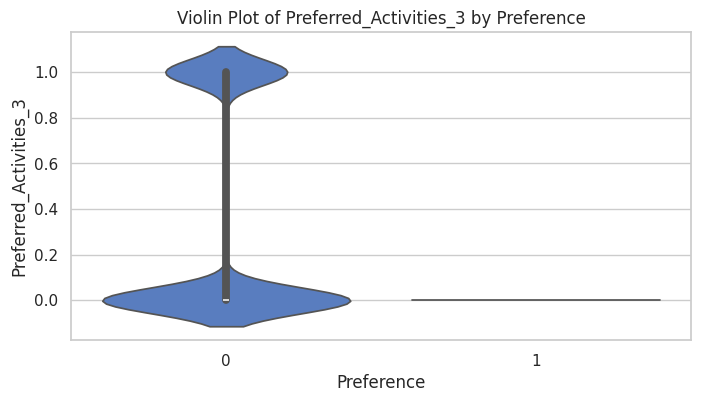

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


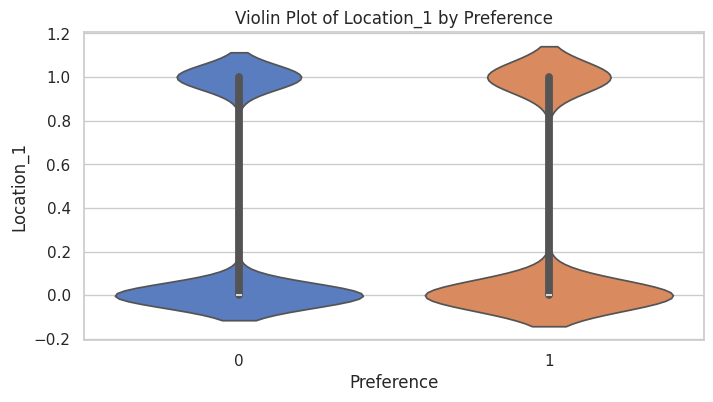

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


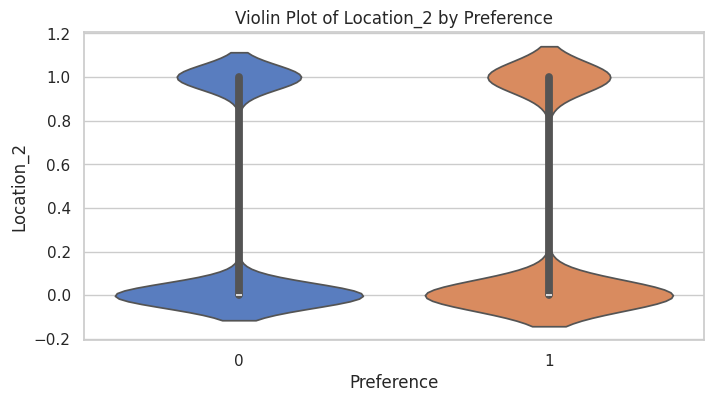

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


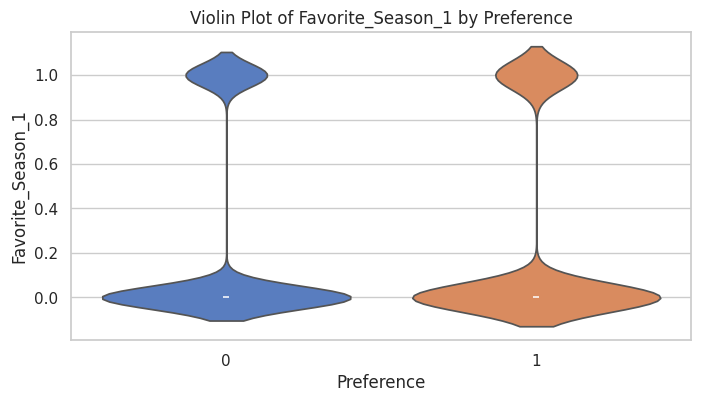

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


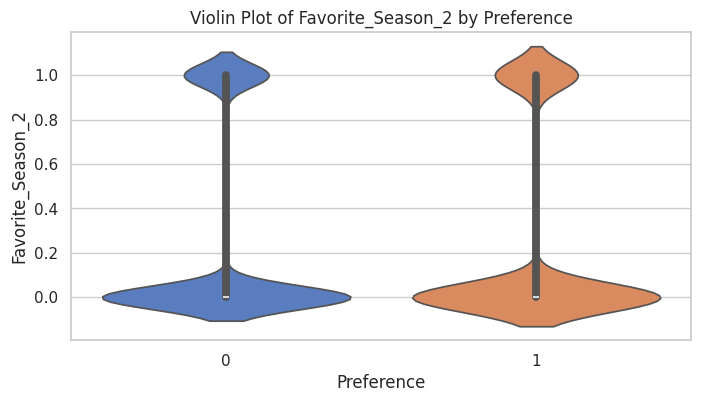

<ipython-input-72-9bcb8b6db018>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Preference', y=column, palette='muted')


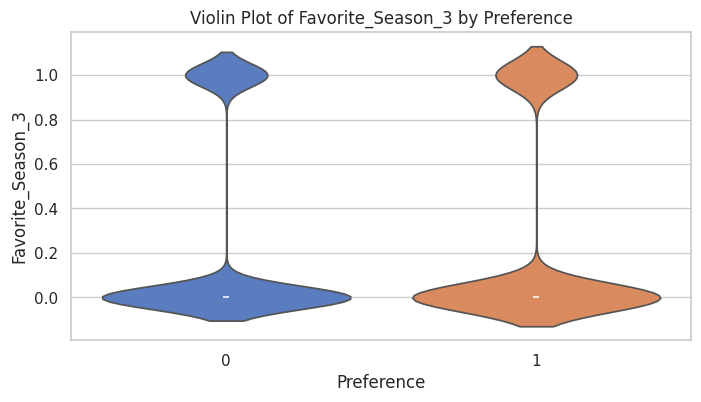

In [72]:
# Plot 4: Violin plots for numerical features by target variable
for column in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.violinplot(data=data, x='Preference', y=column, palette='muted')
    plt.title(f'Violin Plot of {column} by Preference')
    plt.show()


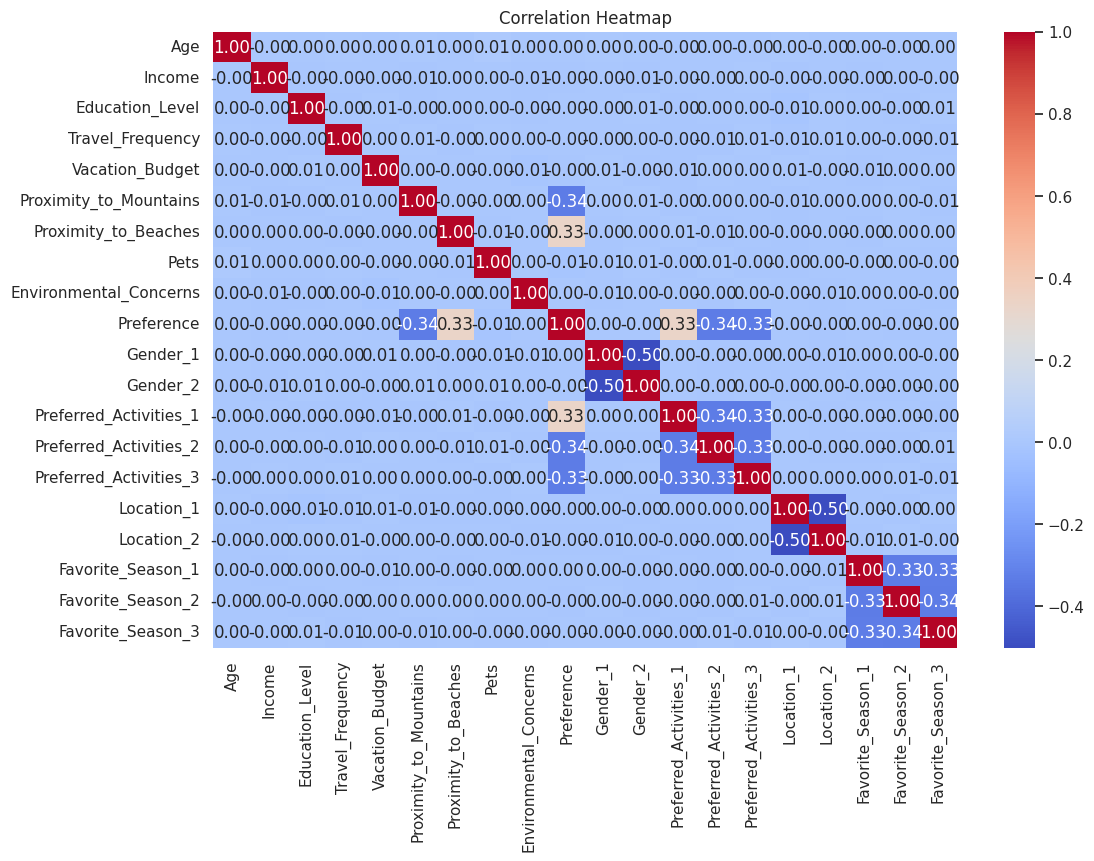

In [73]:
# Plot 5: Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

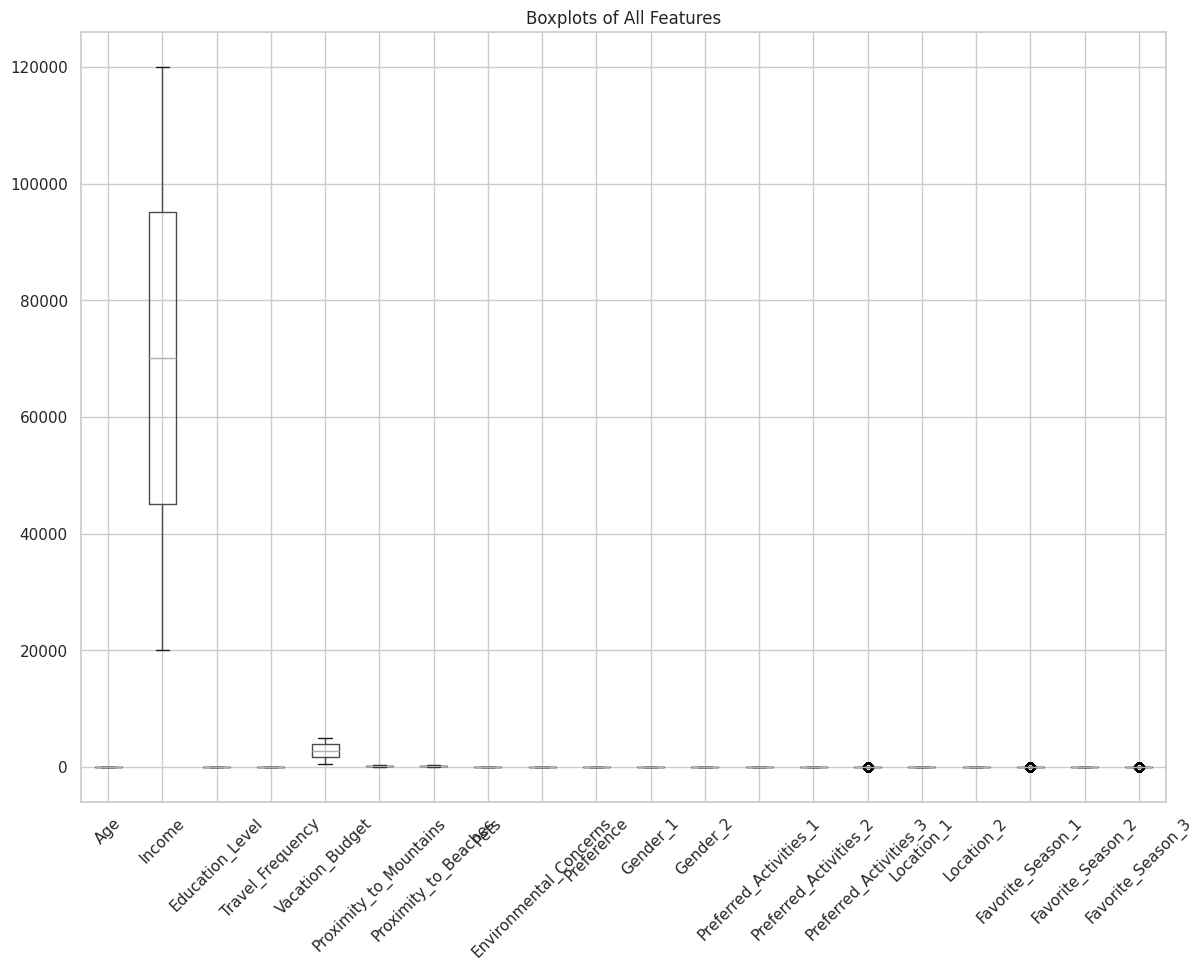

In [74]:
# Plot 6: Boxplots for All Features
plt.figure(figsize=(14, 10))
data.boxplot()
plt.title("Boxplots of All Features")
plt.xticks(rotation=45)
plt.show()

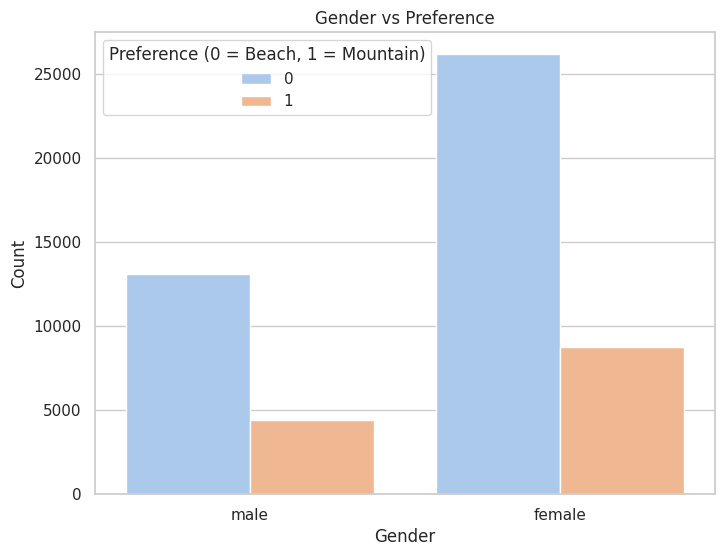

In [80]:
# Reconstruct Gender column
encoded_data['Gender'] = encoded_data['Gender_1'].apply(lambda x: 'male' if x == 1 else 'female')

#Plot 7: Plot Gender vs Preference
plt.figure(figsize=(8, 6))
sns.countplot(data=encoded_data, x='Gender', hue='Preference', palette='pastel')
plt.title("Gender vs Preference")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Preference (0 = Beach, 1 = Mountain)")
plt.show()


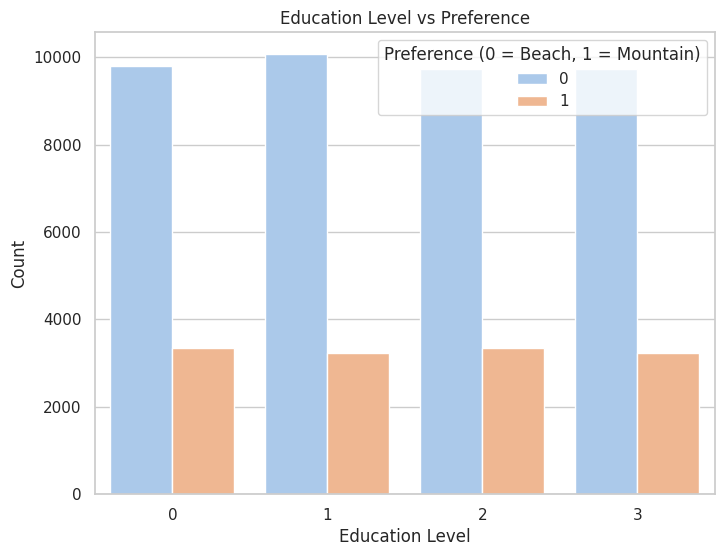

In [81]:
# Plot 8: Education Level vs Preference
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Education_Level', hue='Preference', palette='pastel')
plt.title("Education Level vs Preference")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.legend(title="Preference (0 = Beach, 1 = Mountain)")
plt.show()

<Figure size 800x600 with 0 Axes>

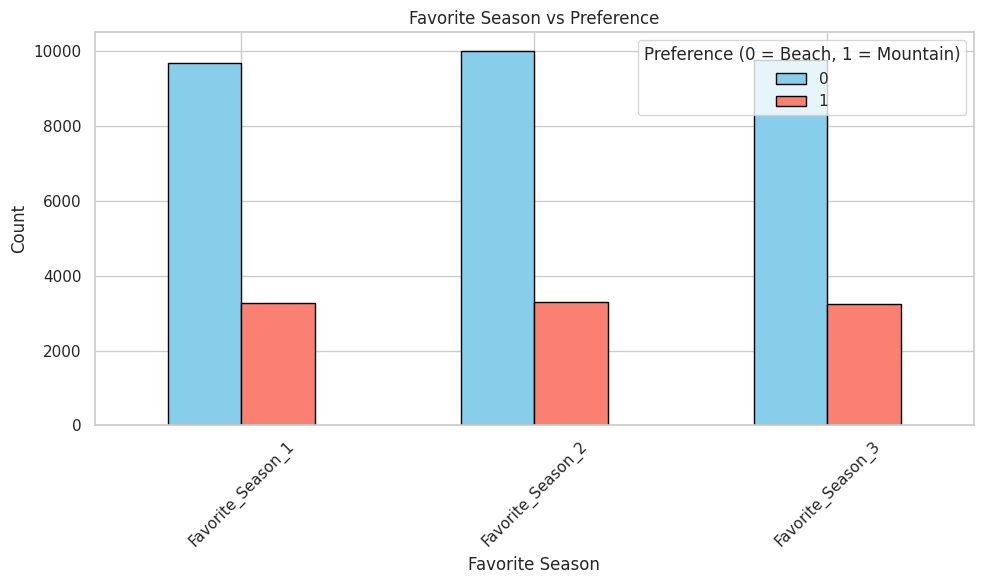

In [88]:
# Plot 10: Favorite Season vs Preference
plt.figure(figsize=(8, 6))

# Filter columns related to Favorite Season
favorite_season_columns = [col for col in data.columns if 'Favorite_Season_' in col]

# Group by Preference and calculate counts for each season
favorite_season_counts = data.groupby('Preference')[favorite_season_columns].sum()

# Ensure both Preference categories are included
for col in [0, 1]:  # 0 = Beach, 1 = Mountain
    if col not in favorite_season_counts.index:
        favorite_season_counts.loc[col] = 0

# Transpose for plotting
favorite_season_counts = favorite_season_counts.T

# Plot the data
favorite_season_counts.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'], edgecolor='black')
plt.title("Favorite Season vs Preference")
plt.xlabel("Favorite Season")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Preference (0 = Beach, 1 = Mountain)", loc='upper right')
plt.tight_layout()
plt.show()


## Splitting Dataset and Balancing Training Data with SMOTE

In [95]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Step 9: Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Step 4: Print the new class distribution
print("Original training class distribution:")
print(y_train.value_counts())
print("\nBalanced training class distribution after SMOTE:")
print(y_train_balanced.value_counts())

print("")
# Display the shapes of the balanced training and testing subsets

print("Shapes of Training and Testing Subsets:")
print(f"X_train_balanced: {X_train_balanced.shape}")
print(f"y_train_balanced: {y_train_balanced.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")




Original training class distribution:
Preference
0    31437
1    10518
Name: count, dtype: int64

Balanced training class distribution after SMOTE:
Preference
1    31437
0    31437
Name: count, dtype: int64

Shapes of Training and Testing Subsets:
X_train_balanced: (62874, 19)
y_train_balanced: (62874,)
X_test: (10489, 19)
y_test: (10489,)


## Visualizing Class Distribution After SMOTE

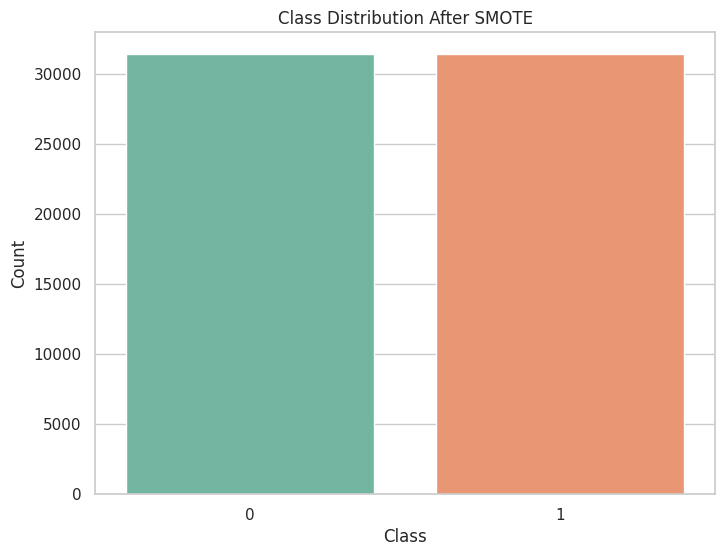

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert y_train_balanced to a DataFrame for visualization
y_train_balanced_df = pd.DataFrame({'Class': y_train_balanced})

# Plot the distribution after SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(data=y_train_balanced_df, x='Class', hue='Class', palette='Set2', legend=False)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


## Standardizering the Data

In [97]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Initialize the StandardScaler
scaler = StandardScaler()

# Step 2: Fit the scaler on the balanced training data and transform both training and testing datasets
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)  # Fit and transform on balanced training data
X_test_scaled = scaler.transform(X_test)  # Transform test data using the same scaler

# Step 3: Initialize PCA
pca = PCA(n_components=0.95)  # Retain 95% of the variance

# Step 4: Fit PCA on the balanced and scaled training data
X_train_balanced_scaled_pca = pca.fit_transform(X_train_balanced_scaled)

# Step 5: Transform the test data using the same PCA
X_test_scaled_pca = pca.transform(X_test_scaled)

# Step 6: Optional - Convert back to DataFrame for easier interpretation
X_train_balanced_scaled_pca = pd.DataFrame(X_train_balanced_scaled_pca)
X_test_scaled_pca = pd.DataFrame(X_test_scaled_pca)

# Display the number of components retained
print(f"Number of PCA components retained: {pca.n_components_}")

# Display the first few rows of the PCA-transformed training data
print("PCA Transformed Balanced Training Data:")
print(X_train_balanced_scaled_pca.head())

print("\nPCA Transformed Testing Data:")
print(X_test_scaled_pca.head())



Number of PCA components retained: 17
PCA Transformed Balanced Training Data:
         0         1         2         3         4         5         6   \
0  0.284916  0.966098  1.131578 -0.501952  1.978985 -0.597198  2.259065   
1  0.742051  2.407443  0.405913 -0.798625 -1.916710 -1.703924 -1.056020   
2  0.182763  1.009067  1.399978 -1.438075 -1.440939 -0.156296  2.028147   
3  0.119884  1.027511  1.402706 -1.873216 -1.069942  1.788781 -1.278465   
4  0.731880  1.247018 -1.042427  0.596826 -0.552172 -1.711222 -0.737265   

         7         8         9         10        11        12        13  \
0 -1.174053 -0.664603  0.036749 -1.502324 -2.802919  0.959453  0.752710   
1  1.185540  0.883724  0.146149  0.873021  1.270816  0.058538 -0.617222   
2  1.107049  1.243682  0.822161  0.384058 -1.343276 -0.703898  1.350593   
3 -0.273818 -1.142169  0.725826  0.179572  0.509986 -0.274292  0.193685   
4 -0.933854  0.689905 -1.414187 -1.001161  0.529372  0.751416 -0.059641   

         14        1

# Step 1. The 3 chosen classifiers are

1. Decision Tree
2. Support Vector Machine
3. Neural Network

# Step 2: Model Implementation

# Step 3: Model Optimization and Improvement

# **Decision Tree**

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, LeaveOneOut
from scipy.stats import randint
from sklearn.experimental import enable_halving_search_cv  # Enable HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV

In [103]:
# Use the PCA-transformed balanced training dataset
X_train = X_train_balanced_scaled_pca
y_train = y_train_balanced

In [109]:
# Initialize the Decision Tree Classifier with the entropy criterion
classifier = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42)

# Train the classifier
classifier.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [110]:
# Evaluate the model on the training data
train_predictions = classifier.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Data Accuracy:", train_accuracy)

# Detailed performance metrics for the training set
print("\nClassification Report for Training Data:")
print(classification_report(y_train, train_predictions))

# Confusion matrix for the training set
print("Confusion Matrix for Training Data:")
print(confusion_matrix(y_train, train_predictions))

# Evaluate the model on the PCA-transformed test data
test_predictions = classifier.predict(X_test_scaled_pca)  # Use PCA-transformed test data
test_accuracy = accuracy_score(y_test, test_predictions)
print("\nTest Data Accuracy:", test_accuracy)

# Detailed performance metrics for the test set
print("\nClassification Report for Test Data:")
print(classification_report(y_test, test_predictions))

# Confusion matrix for the test set
print("Confusion Matrix for Test Data:")
print(confusion_matrix(y_test, test_predictions))


Training Data Accuracy: 1.0

Classification Report for Training Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31437
           1       1.00      1.00      1.00     31437

    accuracy                           1.00     62874
   macro avg       1.00      1.00      1.00     62874
weighted avg       1.00      1.00      1.00     62874

Confusion Matrix for Training Data:
[[31437     0]
 [    0 31437]]

Test Data Accuracy: 0.9766421965869005

Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7859
           1       0.95      0.96      0.95      2630

    accuracy                           0.98     10489
   macro avg       0.97      0.97      0.97     10489
weighted avg       0.98      0.98      0.98     10489

Confusion Matrix for Test Data:
[[7713  146]
 [  99 2531]]


# Use of model validation concept seen in the assignment 2.

# K-Fold Cross-Validation

In [106]:
# Perform K-Fold Cross-Validation on the balanced training data
dt_classifier = DecisionTreeClassifier(random_state=42)
kfold_scores = cross_val_score(dt_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("\nK-Fold Cross-Validation Results for Decision Tree:")
print(f"Mean Accuracy: {kfold_scores.mean():.4f} | Std Dev: {kfold_scores.std():.4f}")



K-Fold Cross-Validation Results for Decision Tree:
Mean Accuracy: 0.9790 | Std Dev: 0.0112


# Leave-One-Out

In [ ]:
# Perform Leave-One-Out Cross-Validation
loo = LeaveOneOut()
loo_scores = cross_val_score(dt_classifier, X_train, y_train, cv=loo, scoring='accuracy')
print("\nLeave-One-Out Cross-Validation Results for Decision Tree:")
print(f"Mean Accuracy: {loo_scores.mean():.4f}")


Leave-One-Out Cross-Validation Results for Decision Tree:
Mean Accuracy: 0.9974


# Grid Search

In [107]:
# Grid Search
param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_dt = GridSearchCV(estimator=dt_classifier, param_grid=param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)
print("\nGrid Search Results for Decision Tree:")
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Best Score: {grid_search_dt.best_score_:.4f}")


Grid Search Results for Decision Tree:
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Score: 0.9802


# Randomized Search

In [ ]:
# Randomized Search
param_distributions_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}
random_search_dt = RandomizedSearchCV(estimator=dt_classifier, param_distributions=param_distributions_dt,
                                      n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search_dt.fit(X_train, y_train)
print("\nRandomized Search Results for Decision Tree:")
print(f"Best Parameters: {random_search_dt.best_params_}")
print(f"Best Score: {random_search_dt.best_score_:.4f}")


Randomized Search Results for Decision Tree:
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 12}
Best Score: 0.9965


# Halving Grid Search

In [ ]:
# Halving Grid Search
param_grid_dt_halving = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
halving_grid_search_dt = HalvingGridSearchCV(estimator=dt_classifier, param_grid=param_grid_dt_halving,
                                             cv=5, scoring='accuracy', factor=2)
halving_grid_search_dt.fit(X_train, y_train)
print("\nHalving Grid Search Results for Decision Tree:")
print(f"Best Parameters: {halving_grid_search_dt.best_params_}")
print(f"Best Score: {halving_grid_search_dt.best_score_:.4f}")


Halving Grid Search Results for Decision Tree:
Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Score: 0.9966


# **Support Vector Machine (SVM)**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, LeaveOneOut
from scipy.stats import uniform
from sklearn.experimental import enable_halving_search_cv  # Enable HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV

In [ ]:
# Use the PCA-transformed balanced training dataset
X_train = X_train_balanced_scaled_pca
y_train = y_train_balanced

In [ ]:
# Initialize the SVM Classifier
svm_classifier = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

# Train the classifier
svm_classifier.fit(X_train, y_train)

SVC(C=1, random_state=42)

In [ ]:
# Evaluate the model on the balanced training data
train_predictions_svm = svm_classifier.predict(X_train)
train_accuracy_svm = accuracy_score(y_train, train_predictions_svm)
print("Training Data Accuracy (SVM):", train_accuracy_svm)

# Detailed performance metrics for the training set
print("\nClassification Report for Training Data (SVM):")
print(classification_report(y_train, train_predictions_svm))

# Confusion matrix for the training set
print("Confusion Matrix for Training Data (SVM):")
print(confusion_matrix(y_train, train_predictions_svm))

# Evaluate the model on the PCA-transformed test data
test_predictions_svm = svm_classifier.predict(X_test_scaled_pca)  # Use PCA-transformed test data
test_accuracy_svm = accuracy_score(y_test, test_predictions_svm)
print("\nTest Data Accuracy (SVM):", test_accuracy_svm)

# Detailed performance metrics for the test set
print("\nClassification Report for Test Data (SVM):")
print(classification_report(y_test, test_predictions_svm))

# Confusion matrix for the test set
print("Confusion Matrix for Test Data (SVM):")
print(confusion_matrix(y_test, test_predictions_svm))


Training Data Accuracy (SVM): 0.9964850335591818

Classification Report for Training Data (SVM):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     31437
           1       0.99      1.00      1.00     31437

    accuracy                           1.00     62874
   macro avg       1.00      1.00      1.00     62874
weighted avg       1.00      1.00      1.00     62874

Confusion Matrix for Training Data (SVM):
[[31274   163]
 [   58 31379]]

Test Data Accuracy (SVM): 0.9860806559252551

Classification Report for Test Data (SVM):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7859
           1       0.96      0.98      0.97      2630

    accuracy                           0.99     10489
   macro avg       0.98      0.98      0.98     10489
weighted avg       0.99      0.99      0.99     10489

Confusion Matrix for Test Data (SVM):
[[7764   95]
 [  51 2579]]


# Use of model validation concept seen in the assignment 2.

# K-Fold Cross-Validation

In [ ]:
# Perform K-Fold Cross-Validation
kfold_scores = cross_val_score(svm_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("\nK-Fold Cross-Validation Results for SVM:")
print(f"Mean Accuracy: {kfold_scores.mean():.4f} | Std Dev: {kfold_scores.std():.4f}")


K-Fold Cross-Validation Results for SVM:
Mean Accuracy: 0.9891 | Std Dev: 0.0067


# Leave-One-Out

In [ ]:
# Perform Leave-One-Out Cross-Validation (on a subset if needed)
loo = LeaveOneOut()
subset_size = 5000  # Reduce size for testing
X_train_subset = X_train[:subset_size]
y_train_subset = y_train[:subset_size]
loo_scores = cross_val_score(svm_classifier, X_train_subset, y_train_subset, cv=loo, scoring='accuracy')
print("\nLeave-One-Out Cross-Validation Results for SVM:")
print(f"Mean Accuracy: {loo_scores.mean():.4f}")


Leave-One-Out Cross-Validation Results for SVM:
Mean Accuracy: 0.9776


# Grid Search

In [ ]:
# Grid Search
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_search_svm = GridSearchCV(estimator=svm_classifier, param_grid=param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)
print("\nGrid Search Results for SVM:")
print(f"Best Parameters: {grid_search_svm.best_params_}")
print(f"Best Score: {grid_search_svm.best_score_:.4f}")


Grid Search Results for SVM:
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.9986


# Randomized Search

In [ ]:
# Randomized Search
param_distributions_svm = {
    'C': uniform(0.1, 10),  # Random range for C
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
random_search_svm = RandomizedSearchCV(estimator=svm_classifier, param_distributions=param_distributions_svm,
                                       n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search_svm.fit(X_train, y_train)
print("\nRandomized Search Results for SVM:")
print(f"Best Parameters: {random_search_svm.best_params_}")
print(f"Best Score: {random_search_svm.best_score_:.4f}")


Randomized Search Results for SVM:
Best Parameters: {'C': 7.41993941811405, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.9985


# Halving Grid Search

In [ ]:
# Halving Grid Search
param_grid_svm_halving = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
halving_grid_search_svm = HalvingGridSearchCV(estimator=svm_classifier, param_grid=param_grid_svm_halving,
                                              cv=5, scoring='accuracy', factor=2)
halving_grid_search_svm.fit(X_train, y_train)
print("\nHalving Grid Search Results for SVM:")
print(f"Best Parameters: {halving_grid_search_svm.best_params_}")
print(f"Best Score: {halving_grid_search_svm.best_score_:.4f}")


Halving Grid Search Results for SVM:
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.9986


# **Neural Network**

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, LeaveOneOut
from scipy.stats import uniform
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

In [ ]:
# Use the PCA-transformed balanced training dataset
X_train = X_train_balanced_scaled_pca
y_train = y_train_balanced

In [ ]:
# Initialize the Neural Network Classifier
nn_classifier = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                               max_iter=300, random_state=42)

# Train the classifier
nn_classifier.fit(X_train, y_train)

MLPClassifier(max_iter=300, random_state=42)

In [ ]:
# Evaluate the model on the balanced training data
train_predictions_nn = nn_classifier.predict(X_train)  # Use PCA-transformed training data
train_accuracy_nn = accuracy_score(y_train, train_predictions_nn)
print("Training Data Accuracy (Neural Network):", train_accuracy_nn)

# Detailed performance metrics for the training set
print("\nClassification Report for Training Data (Neural Network):")
print(classification_report(y_train, train_predictions_nn))

# Confusion matrix for the training set
print("Confusion Matrix for Training Data (Neural Network):")
print(confusion_matrix(y_train, train_predictions_nn))

# Evaluate the model on the PCA-transformed test data
test_predictions_nn = nn_classifier.predict(X_test_scaled_pca)  # Use PCA-transformed test data
test_accuracy_nn = accuracy_score(y_test, test_predictions_nn)
print("\nTest Data Accuracy (Neural Network):", test_accuracy_nn)

# Detailed performance metrics for the test set
print("\nClassification Report for Test Data (Neural Network):")
print(classification_report(y_test, test_predictions_nn))

# Confusion matrix for the test set
print("Confusion Matrix for Test Data (Neural Network):")
print(confusion_matrix(y_test, test_predictions_nn))


Training Data Accuracy (Neural Network): 0.9998409517447594

Classification Report for Training Data (Neural Network):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31437
           1       1.00      1.00      1.00     31437

    accuracy                           1.00     62874
   macro avg       1.00      1.00      1.00     62874
weighted avg       1.00      1.00      1.00     62874

Confusion Matrix for Training Data (Neural Network):
[[31435     2]
 [    8 31429]]

Test Data Accuracy (Neural Network): 0.9973305367527886

Classification Report for Test Data (Neural Network):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7859
           1       1.00      0.99      0.99      2630

    accuracy                           1.00     10489
   macro avg       1.00      1.00      1.00     10489
weighted avg       1.00      1.00      1.00     10489

Confusion Matrix for Test Data 

# Use of model validation concept seen in the assignment 2.

# K-Fold Cross-Validation

In [ ]:
# Perform K-Fold Cross-Validation
kfold_scores = cross_val_score(nn_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("\nK-Fold Cross-Validation Results for Neural Network:")
print(f"Mean Accuracy: {kfold_scores.mean():.4f} | Std Dev: {kfold_scores.std():.4f}")


K-Fold Cross-Validation Results for Neural Network:
Mean Accuracy: 0.9976 | Std Dev: 0.0018


# Leave-One-Out

In [ ]:
# Perform Leave-One-Out Cross-Validation (Subset for efficiency)
subset_size = 500  # Limit to 500 samples to reduce computation time
X_train_subset = X_train[:subset_size]
y_train_subset = y_train[:subset_size]
loo = LeaveOneOut()
loo_scores = cross_val_score(nn_classifier, X_train_subset, y_train_subset, cv=loo, scoring='accuracy')
print("\nSubset Leave-One-Out Cross-Validation Results for Neural Network:")
print(f"Mean Accuracy: {loo_scores.mean():.4f}")


Subset Leave-One-Out Cross-Validation Results for Neural Network:
Mean Accuracy: 0.9680


# Grid Search

In [ ]:
# Grid Search
param_grid_nn = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}
grid_search_nn = GridSearchCV(estimator=nn_classifier, param_grid=param_grid_nn, cv=5, scoring='accuracy')
grid_search_nn.fit(X_train, y_train)
print("\nGrid Search Results for Neural Network:")
print(f"Best Parameters: {grid_search_nn.best_params_}")
print(f"Best Score: {grid_search_nn.best_score_:.4f}")


Grid Search Results for Neural Network:
Best Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}
Best Score: 0.9979


# Randomized Search

In [ ]:
# Randomized Search
param_distributions_nn = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha': uniform(0.0001, 0.01),
    'learning_rate': ['constant', 'adaptive']
}
random_search_nn = RandomizedSearchCV(estimator=nn_classifier, param_distributions=param_distributions_nn,
                                      n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search_nn.fit(X_train, y_train)
print("\nRandomized Search Results for Neural Network:")
print(f"Best Parameters: {random_search_nn.best_params_}")
print(f"Best Score: {random_search_nn.best_score_:.4f}")



Randomized Search Results for Neural Network:
Best Parameters: {'alpha': 0.00010778765841014329, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant'}
Best Score: 0.9979


# Halving Grid Search

In [ ]:
# Halving Grid Search
param_grid_nn_halving = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}
halving_grid_search_nn = HalvingGridSearchCV(estimator=nn_classifier, param_grid=param_grid_nn_halving,
                                             cv=5, scoring='accuracy', factor=2)
halving_grid_search_nn.fit(X_train, y_train)
print("\nHalving Grid Search Results for Neural Network:")
print(f"Best Parameters: {halving_grid_search_nn.best_params_}")
print(f"Best Score: {halving_grid_search_nn.best_score_:.4f}")


Halving Grid Search Results for Neural Network:
Best Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}
Best Score: 0.9976


# Visualize Learning Curve

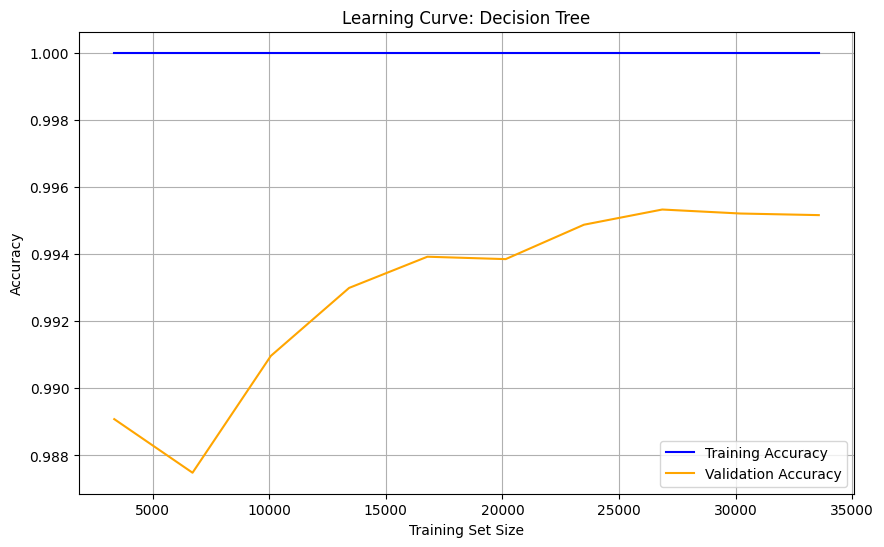

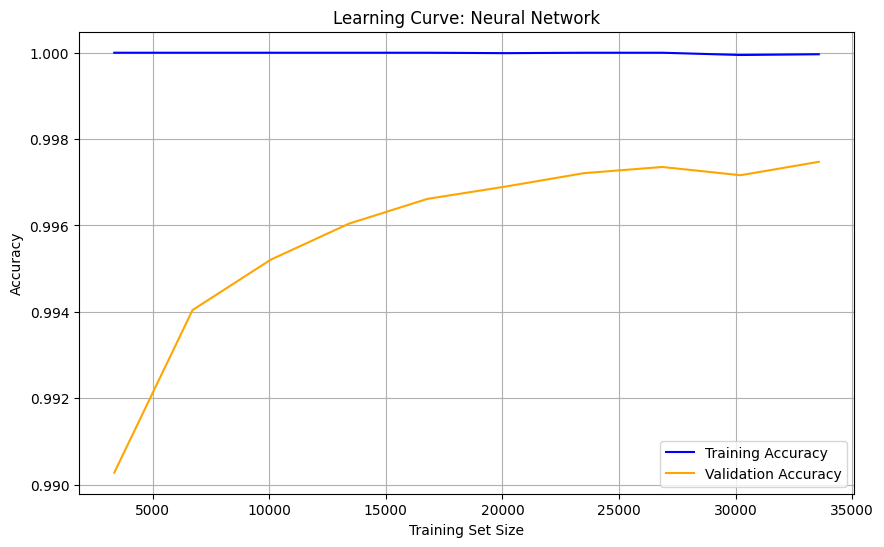

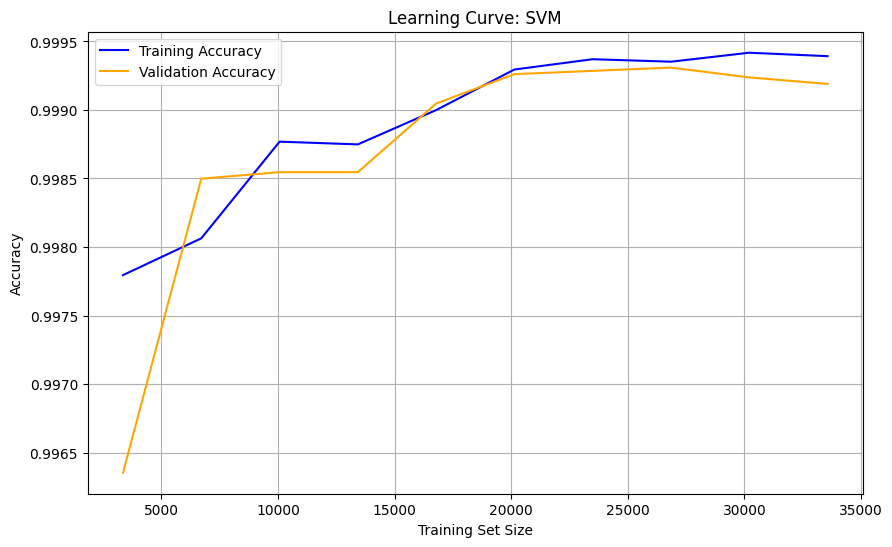

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue')
    plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy', color='orange')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
plot_learning_curve(DecisionTreeClassifier(max_depth=15, random_state=42), X_train_balanced_scaled_pca, y_train, "Learning Curve: Decision Tree")
plot_learning_curve(MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42), X_train_balanced_scaled_pca, y_train, "Learning Curve: Neural Network")
plot_learning_curve(SVC(kernel='linear', C=10, random_state=42), X_train_balanced_scaled_pca, y_train, "Learning Curve: SVM")


# Training vs. Validation Accuracy Plot

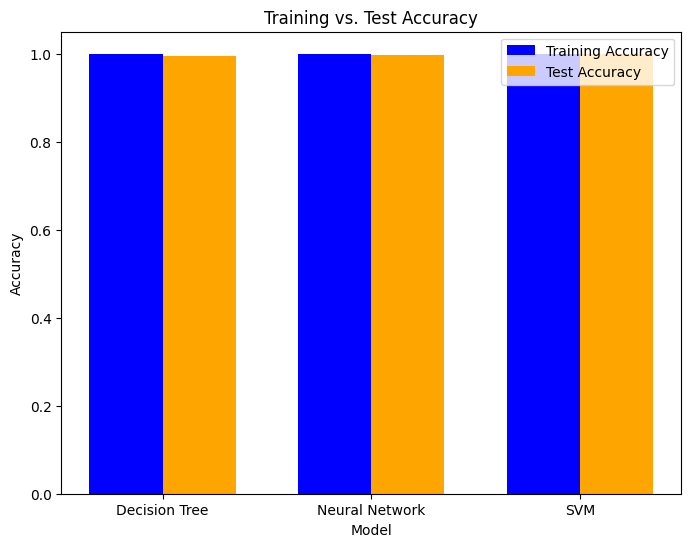

In [ ]:
# Example: Training and Test Accuracy Plot
models = [
    ("Decision Tree", DecisionTreeClassifier(max_depth=15, random_state=42)),
    ("Neural Network", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)),
    ("SVM", SVC(kernel='linear', C=10, random_state=42))
]

train_acc = []
test_acc = []

for name, model in models:
    model.fit(X_train_balanced_scaled_pca, y_train)
    train_acc.append(model.score(X_train_balanced_scaled_pca, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 6))
bar_width = 0.35
x = np.arange(len(models))

plt.bar(x - bar_width/2, train_acc, width=bar_width, label='Training Accuracy', color='blue')
plt.bar(x + bar_width/2, test_acc, width=bar_width, label='Test Accuracy', color='orange')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Training vs. Test Accuracy')
plt.xticks(x, [name for name, _ in models])
plt.legend()
plt.show()
